# Flow Network

## Flow network example from Wikipedia
Network capacity is full

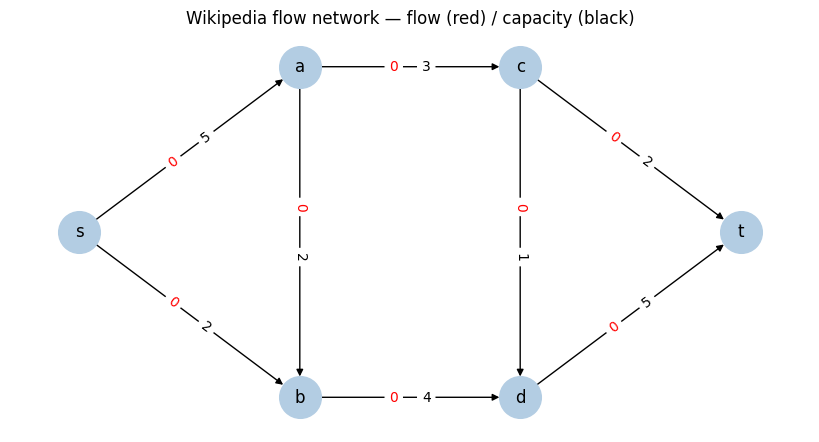

In [1]:
from flow_network import draw_network
import networkx as nx



G = nx.DiGraph()

# Nodes: source 's', intermediates 'a','b','c','d', sink 't' (6 nodes)
G.add_nodes_from(["s", "a", "b", "c", "d", "t"])

# Add directed edges with capacities
edges = [
    ("s", "a", 5),
    ("s", "b", 2),
    ("a", "b", 2),
    ("a", "c", 3),
    ("b", "d", 4),
    ("c", "d", 1),
    ("c", "t", 2),
    ("d", "t", 5),
]

for u, v, cap in edges:
    G.add_edge(u, v, capacity=cap)
draw_network(G)

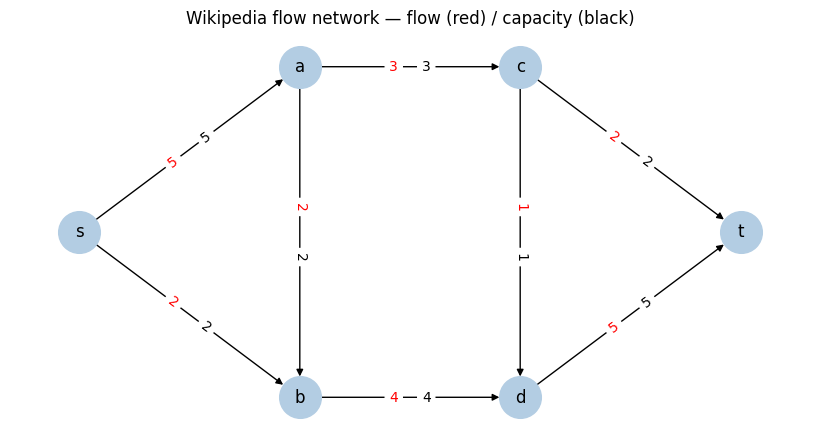

{'s': {'a': 5, 'b': 2},
 'a': {'b': 2, 'c': 3},
 'b': {'d': 4},
 'c': {'d': 1, 't': 2},
 'd': {'t': 5},
 't': {}}

In [2]:
import networkx as nx
_, flow = nx.maximum_flow(G, "s", "t", capacity="capacity")
draw_network(G, flow)
flow

# Max flow - under capacity

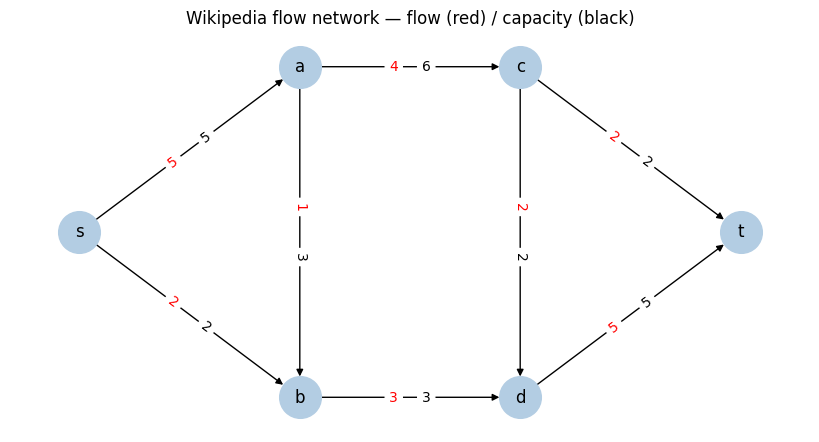

{'s': {'a': 5, 'b': 2},
 'a': {'b': 1, 'c': 4},
 'b': {'d': 3},
 'c': {'d': 2, 't': 2},
 'd': {'t': 5},
 't': {}}

In [3]:
G = nx.DiGraph()

# Nodes: source 's', intermediates 'a','b','c','d', sink 't' (6 nodes)
G.add_nodes_from(["s", "a", "b", "c", "d", "t"])

# Add directed edges with capacities
edges = [
    ("s", "a", 5),
    ("s", "b", 2),
    ("a", "b", 3),
    ("a", "c", 6),
    ("b", "d", 3),
    ("c", "d", 2),
    ("c", "t", 2),
    ("d", "t", 5),
]

for u, v, cap in edges:
    G.add_edge(u, v, capacity=cap)
_, flow = nx.maximum_flow(G, "s", "t", capacity="capacity")
draw_network(G, flow)
flow

optimal value: 2.3025850909932926
(edge, flow): [(('s', 'a'), np.float64(5.0)), (('s', 'b'), np.float64(2.0)), (('a', 'b'), np.float64(1.0)), (('a', 'c'), np.float64(4.0)), (('b', 'd'), np.float64(3.0)), (('c', 'd'), np.float64(2.0)), (('c', 't'), np.float64(2.0)), (('d', 't'), np.float64(5.0))]


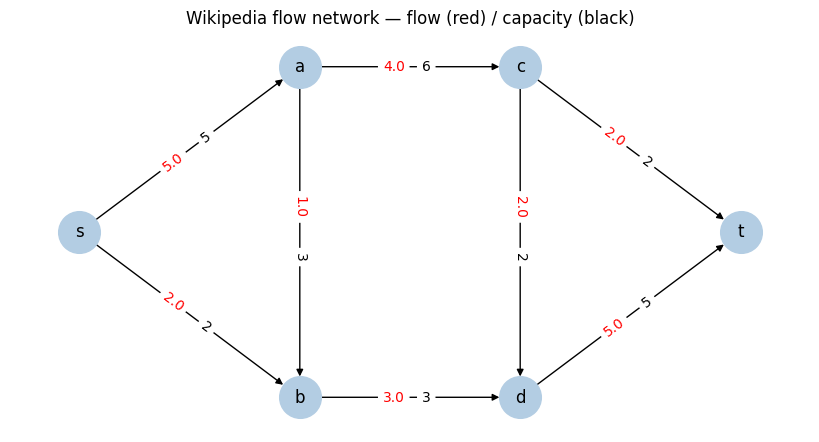

In [ ]:
import cvxpy as cp

import numpy as np



node_list = [n for n in G.nodes() if n not in ("s", "t")]

edge_list = list(G.edges())

edge_array = np.array(edge_list, dtype=object)



A_full = np.asarray(nx.incidence_matrix(G, oriented=True, dtype=int).todense())
A = A_full[1:-1, :]

A_drop = np.delete(A_full, [0, -1], axis=0)

A_take = np.take(A_full, np.arange(1, A_full.shape[0] - 1), axis=0)

A_mask = A_full[np.isin(list(G.nodes()), ["s", "t"], invert=True)]



c = np.array([G[u][v]["capacity"] for u, v in edge_list], dtype=float)

# Create the vector q for the objective function
q = (edge_array[:, 0] == "s").astype(int) - (edge_array[:, 1] == "s").astype(int)



x = cp.Variable(len(edge_list), pos=True)



objective = cp.Maximize(q @ x)
objective = cp.Maximize(q @ cp.log(x))

constraints = [
    x <= c,
    A @ x == 0,

]



problem = cp.Problem(objective, constraints)

optimal_value = problem.solve()



cp_flow = np.round(x.value, 2)

edge_flow = dict(zip(edge_list, cp_flow))

cp_flow_dict = {u: {} for u in G.nodes()}

for (u, v), f in edge_flow.items():

    cp_flow_dict[u][v] = float(f)



print("optimal value:", optimal_value)

print("(edge, flow):", list(edge_flow.items()))

draw_network(G, cp_flow_dict)


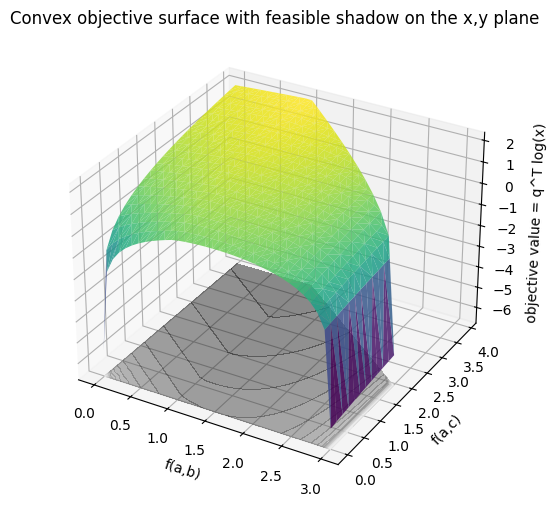

In [ ]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

import matplotlib.pyplot as plt



# 3D surface over fixed f(a,b) and f(a,c)

i_ab = edge_list.index(("a", "b"))
i_ac = edge_list.index(("a", "c"))
c_ab = c[i_ab]
c_ac = c[i_ac]



eps = 1e-3
ab_vals = np.linspace(eps, c_ab - eps, 35)
ac_vals = np.linspace(eps, c_ac - eps, 35)



ab_grid, ac_grid = np.meshgrid(ab_vals, ac_vals)
z_obj = np.full_like(ab_grid, np.nan, dtype=float)



for r in range(ab_grid.shape[0]):
    for s in range(ab_grid.shape[1]):
        fab = float(ab_grid[r, s])
        fac = float(ac_grid[r, s])

        X = cp.Variable(len(edge_list), pos=True)
        cons = [
            X <= c,
            A @ X == 0,
            X[i_ab] == fab,
            X[i_ac] == fac,
        ]

        obj = cp.Maximize(q @ cp.log(X))
        prob = cp.Problem(obj, cons)
        prob.solve()

        if prob.status in (cp.OPTIMAL, cp.OPTIMAL_INACCURATE) and X.value is not None:
            z_obj[r, s] = prob.value



fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")

valid = ~np.isnan(z_obj)
if not np.any(valid):
    raise ValueError("No feasible points found for the (f(a,b), f(a,c)) grid.")

z_valid = z_obj[valid]
z_min = float(np.min(z_valid))
z_max = float(np.max(z_valid))
z_floor = z_min - 0.12 * max(z_max - z_min, 1.0)


ax.plot_trisurf(ab_grid[valid], ac_grid[valid], z_obj[valid], alpha=0.85, cmap="viridis")
ax.tricontourf(
    ab_grid[valid],
    ac_grid[valid],
    z_obj[valid],
    zdir="z",
    offset=z_floor,
    levels=20,
    cmap="Greys",
    alpha=0.45,
)

ax.set_xlabel("f(a,b)")
ax.set_ylabel("f(a,c)")
ax.set_zlabel("objective value = q^T log(x)")
ax.set_zlim(z_floor, z_max + 0.1)
ax.set_title("Convex objective surface with feasible shadow on the x,y plane")

plt.show()
